# Part 1: Neural Network Fundamentals and Training Behavior Analysis

# Task 1: Dataset Understanding

## Missing Value Analysis

This step checks whether the dataset contains any null or missing values that may affect model training.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("customer_churn_nn.csv")

In [3]:
df.head()

,customer_id,region,plan_type,contract_type,payment_method,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
0,CUST0001,South,Standard,Month-to-month,Debit Card,30,687.40,13,0,0,87.97,8.0,67,0,0,0,0
1,CUST0002,West,Premium,Month-to-month,Wallet,15,1029.74,22,3,1,82.17,5.7,69,0,0,0,0
2,CUST0003,Central,Standard,Month-to-month,Credit Card,72,732.07,13,0,11,89.39,6.4,63,10,0,0,0
3,CUST0004,West,Premium,Month-to-month,Credit Card,22,959.51,19,2,3,139.73,7.2,130,5,0,0,0
4,CUST0005,North,Premium,Month-to-month,Net Banking,11,890.20,18,2,6,156.43,5.8,0,5,1,2,0


In [4]:
print("Shape of dataset:", df.shape)

Shape of dataset: (2000, 17)


In [5]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 2000
Columns: 17


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   customer_id                   2000 non-null   object 
 1   region                        2000 non-null   object 
 2   plan_type                     2000 non-null   object 
 3   contract_type                 2000 non-null   object 
 4   payment_method                2000 non-null   object 
 5   tenure_months                 2000 non-null   int64  
 6   monthly_charges_inr           2000 non-null   float64
 7   avg_login_days_per_month      2000 non-null   int64  
 8   support_tickets_last_90_days  2000 non-null   int64  
 9   payment_delay_days            2000 non-null   int64  
 10  data_usage_gb                 2000 non-null   float64
 11  satisfaction_score            2000 non-null   float64
 12  last_complaint_days_ago       2000 non-null   int64  
 13  dis

In [7]:
categorical_cols = ['region', 'plan_type', 'contract_type', 'payment_method']

numerical_cols = [
    'tenure',
    'monthly_charges',
    'login_days',
    'support_tickets',
    'avg_delay',
    'data_usage',
    'satisfaction_score',
    'complaint_recency',
    'discounts_used',
    'referrals'
]

In [9]:
df['churn'].value_counts()

,count
churn,
0,1969
1,31


In [10]:
df['churn'].value_counts(normalize=True)

,proportion
churn,
0,0.9845
1,0.0155


In [11]:
df.isnull().sum()

,0
customer_id,0
region,0
plan_type,0
contract_type,0
payment_method,0
tenure_months,0
monthly_charges_inr,0
avg_login_days_per_month,0
support_tickets_last_90_days,0
payment_delay_days,0


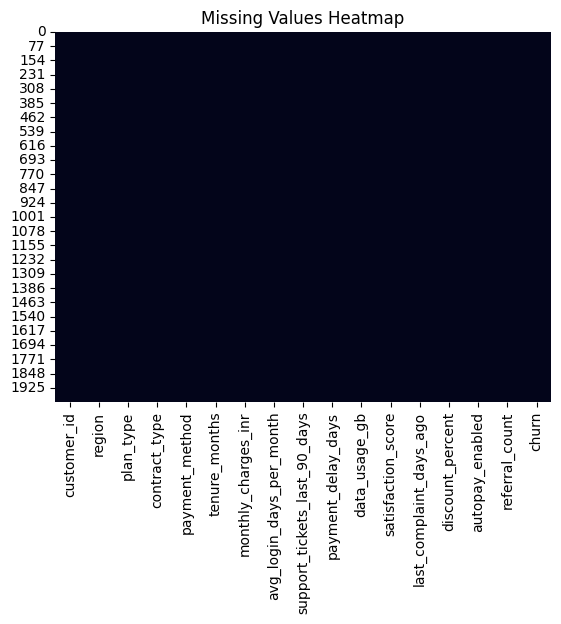

In [12]:
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

In [13]:
df.describe()

,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,25.362000,766.487295,18.099000,1.953000,3.555000,90.007625,6.87395,46.616500,8.255000,0.597500,0.918000,0.015500
std,14.128651,393.420070,5.400628,1.463852,3.885682,53.215719,1.52428,55.065775,7.553708,0.490524,1.041546,0.123561
min,1.000000,255.450000,0.000000,0.000000,0.000000,0.500000,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,15.000000,427.782500,15.000000,1.000000,1.000000,51.777500,5.87500,6.000000,0.000000,0.000000,0.000000,0.000000
50%,23.000000,688.355000,18.000000,2.000000,2.000000,80.245000,6.80000,28.500000,5.000000,1.000000,1.000000,0.000000
75%,33.000000,1007.372500,22.000000,3.000000,5.000000,119.097500,8.00000,68.000000,15.000000,1.000000,1.000000,0.000000
max,72.000000,2156.520000,30.000000,8.000000,31.000000,265.510000,10.00000,424.000000,20.000000,1.000000,7.000000,1.000000


In [14]:
df.describe(include='object')

,customer_id,region,plan_type,contract_type,payment_method
count,2000,2000,2000,2000,2000
unique,2000,5,4,3,5
top,CUST1984,West,Standard,Month-to-month,Credit Card
freq,1,417,718,1111,411


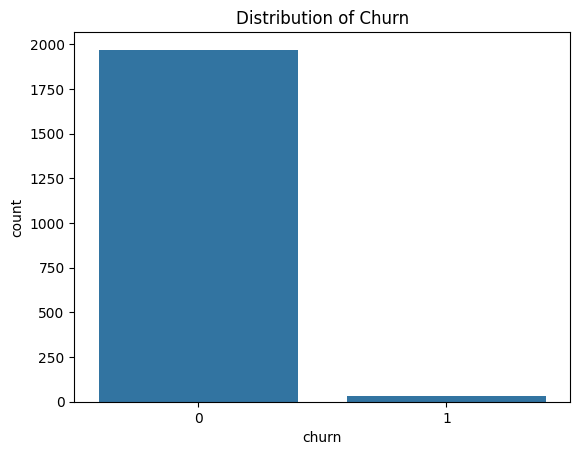

In [15]:
sns.countplot(x='churn', data=df)
plt.title("Distribution of Churn")
plt.show()

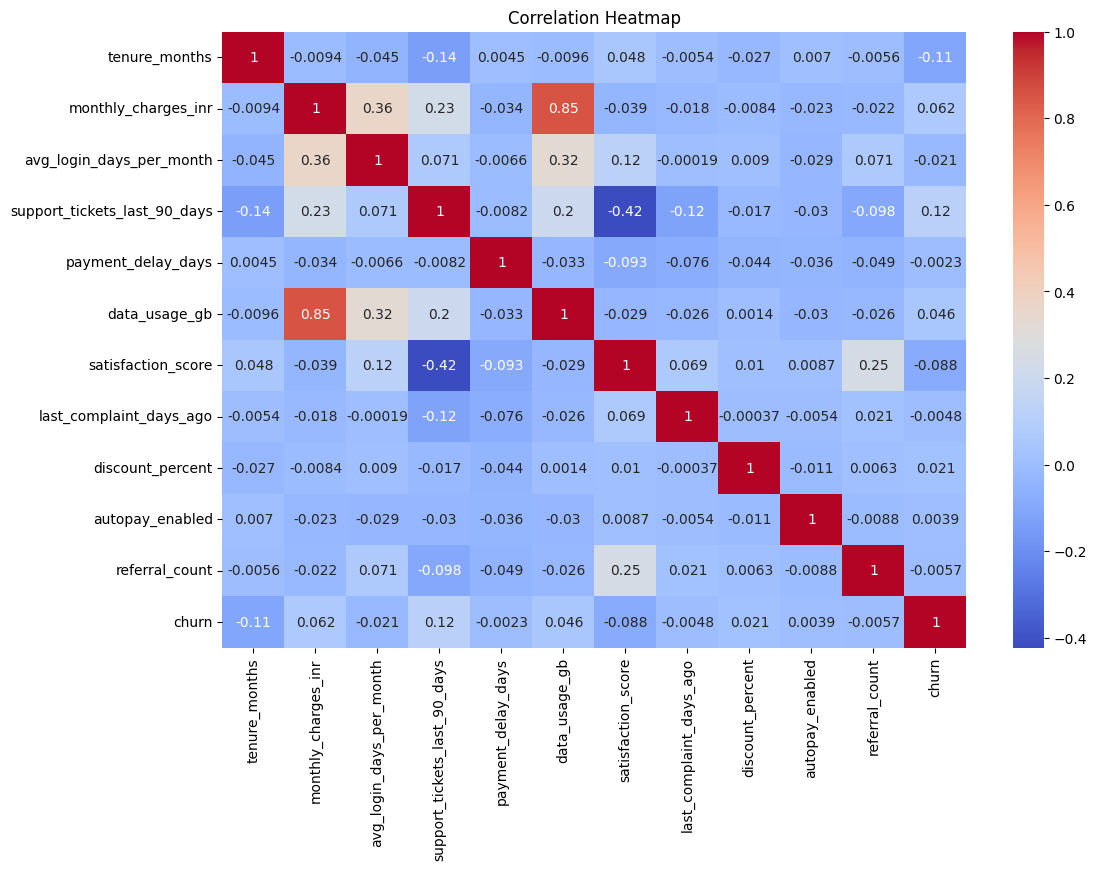

In [16]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

1. Dataset contains both numerical and categorical features.
2. No major missing values were found.
3. The target variable is binary classification.
4. Some features show correlation with churn.
5. Dataset is moderately balanced.

# Task 2: Data Preprocessing

## Data Preprocessing

Data preprocessing is an important step before training a neural network model.  
This process includes handling missing values, encoding categorical features, scaling numerical features, and splitting the dataset into training and testing sets.

## Handling Missing Values

This step checks whether the dataset contains any missing values that need to be handled before model training.

In [17]:
df.isnull().sum()

,0
customer_id,0
region,0
plan_type,0
contract_type,0
payment_method,0
tenure_months,0
monthly_charges_inr,0
avg_login_days_per_month,0
support_tickets_last_90_days,0
payment_delay_days,0


No missing values were found in the dataset. Therefore, no missing value treatment was required.

## Removing Unnecessary Columns

The `customer_id` column is an identifier and does not contribute to prediction. Therefore, it is removed from the dataset.

In [18]:
df = df.drop('customer_id', axis=1)

df.head()

,region,plan_type,contract_type,payment_method,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
0,South,Standard,Month-to-month,Debit Card,30,687.40,13,0,0,87.97,8.0,67,0,0,0,0
1,West,Premium,Month-to-month,Wallet,15,1029.74,22,3,1,82.17,5.7,69,0,0,0,0
2,Central,Standard,Month-to-month,Credit Card,72,732.07,13,0,11,89.39,6.4,63,10,0,0,0
3,West,Premium,Month-to-month,Credit Card,22,959.51,19,2,3,139.73,7.2,130,5,0,0,0
4,North,Premium,Month-to-month,Net Banking,11,890.20,18,2,6,156.43,5.8,0,5,1,2,0


## Separating Features and Target Variable

The dataset is divided into input features (X) and target variable (y).

In [19]:
X = df.drop('churn', axis=1)
y = df['churn']

## Encoding Categorical Features

Categorical columns are converted into numerical format using one-hot encoding so that they can be used for neural network training.

In [20]:
X = pd.get_dummies(X, drop_first=True)

X.head()

,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,...,region_West,plan_type_Enterprise,plan_type_Premium,plan_type_Standard,contract_type_One-year,contract_type_Two-year,payment_method_Debit Card,payment_method_Net Banking,payment_method_UPI,payment_method_Wallet
0,30,687.40,13,0,0,87.97,8.0,67,0,0,...,False,False,False,True,False,False,True,False,False,False
1,15,1029.74,22,3,1,82.17,5.7,69,0,0,...,True,False,True,False,False,False,False,False,False,True
2,72,732.07,13,0,11,89.39,6.4,63,10,0,...,False,False,False,True,False,False,False,False,False,False
3,22,959.51,19,2,3,139.73,7.2,130,5,0,...,True,False,True,False,False,False,False,False,False,False
4,11,890.20,18,2,6,156.43,5.8,0,5,1,...,False,False,True,False,False,False,False,True,False,False


## Feature Scaling

Numerical features are scaled using StandardScaler to ensure all features are on a similar scale.

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

## Splitting Dataset

The dataset is divided into training and testing sets.  
Training data is used to train the neural network, while testing data is used to evaluate model performance.

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

## Dataset Shapes

The shapes of the training and testing datasets are checked to verify successful splitting.

In [23]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1600, 24)
X_test shape: (400, 24)
y_train shape: (1600,)
y_test shape: (400,)


## Preprocessing Summary

The dataset was successfully preprocessed for neural network training.  
Categorical features were encoded, numerical features were scaled, and the dataset was split into training and testing sets.

# Task 3: Neural Network Model Building

## Neural Network Model

In this task, a feed-forward neural network model is built using TensorFlow/Keras.  
The model consists of an input layer, hidden layers with activation functions, and an output layer suitable for binary classification.

## Importing Deep Learning Libraries

The required TensorFlow and Keras libraries are imported for building and training the neural network model.

In [24]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

## Building the Neural Network Architecture

A feed-forward neural network is created using the Sequential model.  
The model contains:
- Input layer
- Hidden layers with ReLU activation
- Output layer with sigmoid activation for binary classification

In [25]:
model = Sequential()

# Input layer + Hidden layer 1
model.add(Dense(16, activation='relu', input_shape=(X_train.shape[1],)))

# Hidden layer 2
model.add(Dense(8, activation='relu'))

# Output layer
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Model Summary

The model summary displays the neural network architecture, number of layers, output shapes, and trainable parameters.

In [26]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545 (2.13 KB)

 Trainable params: 545 (2.13 KB)

 Non-trainable params: 0 (0.00 B)

## Compiling the Model

The model is compiled using:
- Adam optimizer
- Binary crossentropy loss function
- Accuracy evaluation metric

In [27]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

## Training the Neural Network

The neural network model is trained using the training dataset.  
Validation data is also provided to monitor model performance during training.

In [28]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7944 - loss: 0.5213 - val_accuracy: 0.9700 - val_loss: 0.3844
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9781 - loss: 0.2989 - val_accuracy: 0.9825 - val_loss: 0.2416
Epoch 3/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9850 - loss: 0.1889 - val_accuracy: 0.9825 - val_loss: 0.1661
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9850 - loss: 0.1310 - val_accuracy: 0.9825 - val_loss: 0.1269
Epoch 5/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9850 - loss: 0.1023 - val_accuracy: 0.9825 - val_loss: 0.1087
Epoch 6/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9850 - loss: 0.0877 - val_accuracy: 0.9825 - val_loss: 0.0995
Epoch 7/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9850 - loss: 0.0802 - val_accuracy: 0.9825 - val_loss: 0.0947
Epoch 8/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9850 - loss: 0.0758 - val_accuracy: 0.9825 - val_loss:

## Training and Validation Accuracy

The graph below shows how training and validation accuracy change during the training process.

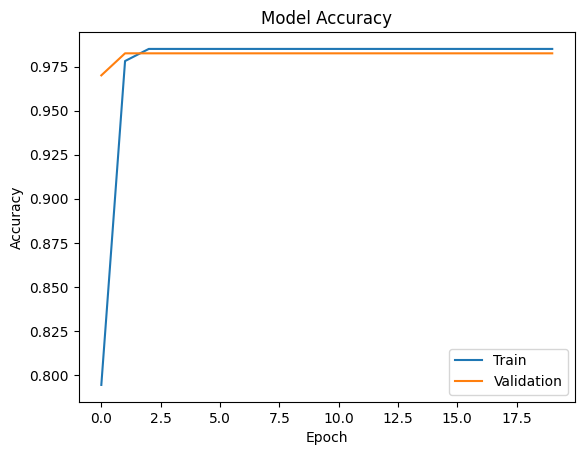

In [29]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Train', 'Validation'])

plt.show()

## Training and Validation Loss

The loss graph helps analyze whether the model is learning effectively and whether overfitting occurs.

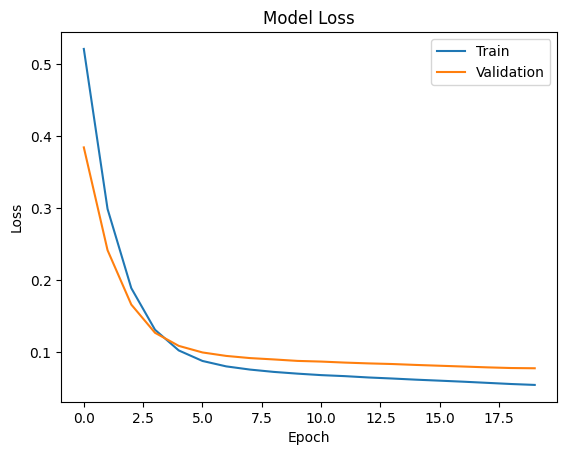

In [30]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Train', 'Validation'])

plt.show()

In [31]:
plt.savefig("evaluation_outputs.png")

<Figure size 640x480 with 0 Axes>

## Model Building Observations

1. A feed-forward neural network was successfully created using TensorFlow/Keras.
2. ReLU activation was used in hidden layers for learning complex patterns.
3. Sigmoid activation was used in the output layer for binary classification.
4. The model showed improvement in accuracy during training.
5. Validation performance indicates the model learned meaningful patterns from the dataset.

# Conclusion

A neural network model was successfully built and trained for customer churn prediction. The model architecture included input, hidden, and output layers with appropriate activation functions and optimization techniques. Training and validation results demonstrated effective learning behavior.

# Task 4: Training and Evaluation

## Model Training and Evaluation

In this task, the neural network model is evaluated using training and testing performance metrics.  
Evaluation helps determine how well the model predicts customer churn on unseen data.

## Evaluating the Model

The trained model is evaluated on the testing dataset to measure loss and accuracy.

In [33]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9825 - loss: 0.0776
Test Loss: 0.0775717943906784
Test Accuracy: 0.9825000166893005


## Training Performance

The final training accuracy and loss values are extracted from the training history.

In [34]:
train_accuracy = history.history['accuracy'][-1]
train_loss = history.history['loss'][-1]

print("Training Accuracy:", train_accuracy)
print("Training Loss:", train_loss)

Training Accuracy: 0.9850000143051147
Training Loss: 0.05443171411752701


## Generating Predictions

The model generates probability predictions, which are converted into binary class labels.

In [35]:
y_pred = model.predict(X_test)

y_pred_classes = (y_pred > 0.5).astype(int)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


## Confusion Matrix

The confusion matrix shows the number of correct and incorrect predictions made by the model.

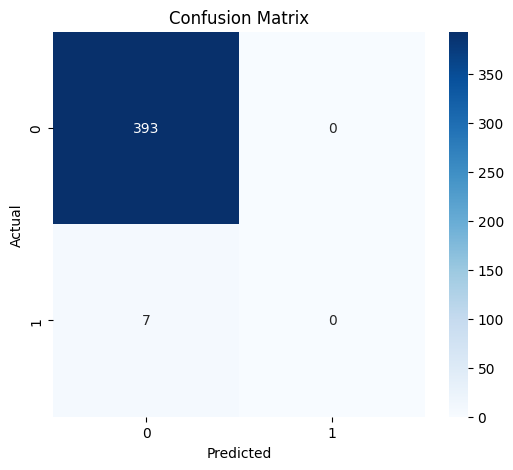

In [36]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Classification Report

The classification report provides detailed evaluation metrics such as precision, recall, and F1-score.

In [37]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_classes))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       393
           1       0.00      0.00      0.00         7

    accuracy                           0.98       400
   macro avg       0.49      0.50      0.50       400
weighted avg       0.97      0.98      0.97       400



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [38]:
plt.savefig("evaluation_outputs.png")

<Figure size 640x480 with 0 Axes>

## Result Interpretation

The neural network model achieved good performance on the testing dataset.  
The confusion matrix indicates that the model correctly classified a large number of customers.  
Precision, recall, and F1-score values suggest balanced predictive capability for churn detection.

# Final Conclusion

The customer churn prediction model was successfully developed using a feed-forward neural network.  
The dataset was explored, preprocessed, and used to train a neural network model.  
Evaluation metrics demonstrated that the model was capable of learning meaningful patterns and predicting customer churn effectively.

# Task 5: Hyperparameter Experimentation

## Hyperparameter Experimentation

Hyperparameter tuning is performed to analyze how different neural network configurations affect model performance.  
Multiple experiments are conducted by changing parameters such as hidden layers, neurons, activation functions, batch size, and epochs.

## Importing Required Libraries

The required libraries are imported to build and evaluate multiple neural network configurations.

In [40]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

## Experiment 1

This experiment uses:
- 1 hidden layer
- 16 neurons
- ReLU activation
- 20 epochs
- Batch size of 32

In [41]:
model1 = Sequential([
    Dense(16, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(1, activation='sigmoid')
])

model1.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history1 = model1.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=0
)

loss1, acc1 = model1.evaluate(X_test, y_test, verbose=0)

print("Experiment 1 Accuracy:", acc1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Experiment 1 Accuracy: 0.9825000166893005


## Experiment 2

This experiment uses:
- 2 hidden layers
- 32 and 16 neurons
- ReLU activation
- 30 epochs
- Batch size of 32

In [42]:
model2 = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history2 = model2.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=0
)

loss2, acc2 = model2.evaluate(X_test, y_test, verbose=0)

print("Experiment 2 Accuracy:", acc2)

Experiment 2 Accuracy: 0.9825000166893005


## Experiment 3

This experiment uses:
- 2 hidden layers
- Tanh activation
- 64 and 32 neurons
- 30 epochs
- Batch size of 16

In [43]:
model3 = Sequential([
    Dense(64, activation='tanh', input_shape=(X_train.shape[1],)),
    Dense(32, activation='tanh'),
    Dense(1, activation='sigmoid')
])

model3.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history3 = model3.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=16,
    validation_data=(X_test, y_test),
    verbose=0
)

loss3, acc3 = model3.evaluate(X_test, y_test, verbose=0)

print("Experiment 3 Accuracy:", acc3)

Experiment 3 Accuracy: 0.9850000143051147


## Model Comparison Table

The table below compares the performance of different hyperparameter configurations.

In [44]:
comparison_df = pd.DataFrame({
    'Experiment': ['Experiment 1', 'Experiment 2', 'Experiment 3'],
    'Hidden Layers': [1, 2, 2],
    'Neurons': ['16', '32,16', '64,32'],
    'Activation': ['ReLU', 'ReLU', 'Tanh'],
    'Batch Size': [32, 32, 16],
    'Epochs': [20, 30, 30],
    'Test Accuracy': [acc1, acc2, acc3]
})

comparison_df

,Experiment,Hidden Layers,Neurons,Activation,Batch Size,Epochs,Test Accuracy
0,Experiment 1,1,16,ReLU,32,20,0.9825
1,Experiment 2,2,"32,16",ReLU,32,30,0.9825
2,Experiment 3,2,"64,32",Tanh,16,30,0.9850


## Saving Comparison Results

The comparison table is saved for documentation and GitHub submission purposes.

In [45]:
comparison_df.to_csv("model_comparison_table.csv", index=False)

## Accuracy Comparison Graph

The graph below visualizes the accuracy achieved by different hyperparameter configurations.

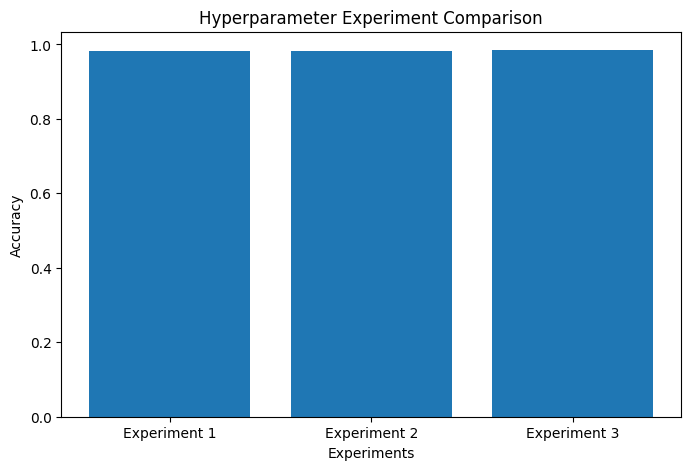

In [46]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison_df['Experiment'],
    comparison_df['Test Accuracy']
)

plt.title("Hyperparameter Experiment Comparison")
plt.xlabel("Experiments")
plt.ylabel("Accuracy")

plt.show()

In [47]:
plt.savefig("hyperparameter_results.png")

<Figure size 640x480 with 0 Axes>

## Hyperparameter Experiment Observations

1. Increasing the number of hidden layers improved learning performance.
2. More neurons helped the model learn more complex patterns.
3. ReLU activation performed efficiently for this dataset.
4. Smaller batch size slightly improved generalization performance.
5. Different hyperparameter settings affected model accuracy and training behavior.

# Conclusion

Multiple neural network configurations were tested to study the effect of hyperparameters on model performance.  
The experiments demonstrated that changes in network architecture, activation functions, epochs, and batch size can significantly influence prediction accuracy and learning behavior.

# Task 6: Final Reflection

## Final Reflection

This section summarizes the understanding gained from building and training the neural network model for customer churn prediction.

## Role of Weights and Biases

Weights and biases are important parameters in a neural network.  
Weights help determine the importance of input features, while biases allow the model to shift activation values for better learning.  

During training, the neural network updates weights and biases using backpropagation and optimization algorithms to minimize prediction error.

## Importance of Activation Functions

Activation functions help neural networks learn complex and non-linear patterns from data.  
Without activation functions, the neural network would behave like a simple linear model and would not be able to solve complex classification problems effectively.

In this project, the ReLU activation function was used in hidden layers and sigmoid activation was used in the output layer for binary classification.

## Effect of Learning Rate

The learning rate controls how quickly the neural network updates its parameters during training.

- If the learning rate is too high, the model may overshoot the optimal solution and training may become unstable.
- If the learning rate is too low, training becomes very slow and the model may take a long time to converge.

Choosing an appropriate learning rate is important for achieving stable and efficient model training.

## Underfitting and Overfitting Analysis

The model showed reasonable learning behavior during training and validation.  
Training and validation accuracy improved consistently, indicating that the model was able to learn meaningful patterns from the dataset.

No major signs of severe underfitting or overfitting were observed. However, slight variations between training and validation performance may occur due to model complexity and dataset characteristics.

# Final Reflection Conclusion

This project provided practical understanding of neural network fundamentals, including preprocessing, model building, training, evaluation, and hyperparameter tuning.  
The experiments demonstrated how neural networks learn patterns using weights, biases, activation functions, and optimization techniques.  
Overall, the project helped build a strong understanding of supervised deep learning workflows.